Conectar con google drive para poder tener acceso a los datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd

In [ ]:
path = '/content/drive/MyDrive/TFG/Data_prueba/esgcclbp'

In [ ]:
print(os.listdir(path))


['bp1dia.txt', 'bp1min.txt', 'cl1dia.txt', 'es1dia.txt', 'cl1min.txt', 'gc1dia.txt', 'es1min.txt', 'gc1min.txt']


Importar ES, min y día para sacar parámetros y extraer información



In [ ]:
df_es1min = pd.read_csv(path+'/es1min.txt')
print(df_es1min.head(), len(df_es1min))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  \
0       ES     I      20151209   70100  2063.00  2063.25  2063.00  2063.25   
1       ES     I      20151209   70200  2063.25  2063.50  2063.00  2063.50   
2       ES     I      20151209   70300  2063.25  2063.50  2063.25  2063.50   
3       ES     I      20151209   70400  2063.50  2063.50  2063.25  2063.50   
4       ES     I      20151209   70500  2063.25  2063.50  2063.25  2063.50   

   <VOL>  <OPENINT>  
0     60          0  
1     37          0  
2     26          0  
3     11          0  
4      6          0   2579332


In [ ]:
df_es1dia = pd.read_csv(path+'/es1dia.txt')
print(df_es1dia.head(), len(df_es1dia))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>   <LOW>  <CLOSE>  \
0       ES     D      19970911       0  918.75  929.75  910.25   916.00   
1       ES     D      19970912       0  918.00  936.50  913.50   918.75   
2       ES     D      19970915       0  933.50  939.75  929.00   931.25   
3       ES     D      19970916       0  931.25  960.00  930.25   956.00   
4       ES     D      19970917       0  956.00  962.50  951.50   956.00   

   <VOL>  <OPENINT>  
0  11825       2909  
1   9759       4059  
2   8551       3818  
3  11749       5314  
4  10849       5516   6601


In [ ]:
df_es1min.columns = df_es1min.columns.str.replace(r"[<>]", "", regex=True).str.upper()
df_es1min['datetime'] = pd.to_datetime(
    df_es1min['DTYYYYMMDD'].astype(str) + df_es1min['TIME'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)
df_es1min = df_es1min.sort_values('datetime')
df_es1min = df_es1min.drop(columns=['DTYYYYMMDD'])
df_es1min = df_es1min.dropna()

df_es1min["datetime"] = pd.to_datetime(df_es1min["datetime"])
df_es1min.set_index("datetime")

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
datetime,,,,,,,,,
2015-12-09 07:01:00,ES,I,70100,2063.00,2063.25,2063.00,2063.25,60,0
2015-12-09 07:02:00,ES,I,70200,2063.25,2063.50,2063.00,2063.50,37,0
2015-12-09 07:03:00,ES,I,70300,2063.25,2063.50,2063.25,2063.50,26,0
2015-12-09 07:04:00,ES,I,70400,2063.50,2063.50,2063.25,2063.50,11,0
2015-12-09 07:05:00,ES,I,70500,2063.25,2063.50,2063.25,2063.50,6,0
...,...,...,...,...,...,...,...,...,...
2023-09-20 11:38:00,ES,I,113800,4497.00,4497.25,4497.00,4497.25,149,0
2023-09-20 11:39:00,ES,I,113900,4497.25,4498.00,4497.25,4497.50,145,0
2023-09-20 11:40:00,ES,I,114000,4497.50,4497.50,4497.00,4497.00,95,0


In [ ]:
df_es1dia.columns = df_es1dia.columns.str.replace(r"[<>]", "", regex=True).str.upper()
df_es1dia['datetime'] = pd.to_datetime(
    df_es1dia['DTYYYYMMDD'].astype(str) + df_es1dia['TIME'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)
df_es1dia = df_es1dia.sort_values('datetime')
df_es1dia = df_es1dia.drop(columns=['DTYYYYMMDD'])
df_es1dia = df_es1dia.dropna()

df_es1dia["datetime"] = pd.to_datetime(df_es1dia["datetime"])
df_es1dia.set_index("datetime")

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
datetime,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516
...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081


In [ ]:
df_es1min

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
0,ES,I,70100,2063.00,2063.25,2063.00,2063.25,60,0,2015-12-09 07:01:00
1,ES,I,70200,2063.25,2063.50,2063.00,2063.50,37,0,2015-12-09 07:02:00
2,ES,I,70300,2063.25,2063.50,2063.25,2063.50,26,0,2015-12-09 07:03:00
3,ES,I,70400,2063.50,2063.50,2063.25,2063.50,11,0,2015-12-09 07:04:00
4,ES,I,70500,2063.25,2063.50,2063.25,2063.50,6,0,2015-12-09 07:05:00
...,...,...,...,...,...,...,...,...,...,...
2579327,ES,I,113800,4497.00,4497.25,4497.00,4497.25,149,0,2023-09-20 11:38:00
2579328,ES,I,113900,4497.25,4498.00,4497.25,4497.50,145,0,2023-09-20 11:39:00
2579329,ES,I,114000,4497.50,4497.50,4497.00,4497.00,95,0,2023-09-20 11:40:00
2579330,ES,I,114100,4497.25,4497.50,4497.00,4497.25,159,0,2023-09-20 11:41:00


In [ ]:
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
0,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11
1,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,1997-09-12
2,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,1997-09-15
3,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,1997-09-16
4,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1997-09-17
...,...,...,...,...,...,...,...,...,...,...
6596,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,2023-09-14
6597,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,2023-09-15
6598,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,2023-09-18
6599,ES,D,0,4503.25,4509.50,4462.25,4492.00,1369869,2229081,2023-09-19


Estadísticas básicas

In [ ]:
df_es1min

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
0,ES,I,70100,2063.00,2063.25,2063.00,2063.25,60,0,2015-12-09 07:01:00
1,ES,I,70200,2063.25,2063.50,2063.00,2063.50,37,0,2015-12-09 07:02:00
2,ES,I,70300,2063.25,2063.50,2063.25,2063.50,26,0,2015-12-09 07:03:00
3,ES,I,70400,2063.50,2063.50,2063.25,2063.50,11,0,2015-12-09 07:04:00
4,ES,I,70500,2063.25,2063.50,2063.25,2063.50,6,0,2015-12-09 07:05:00
...,...,...,...,...,...,...,...,...,...,...
2579327,ES,I,113800,4497.00,4497.25,4497.00,4497.25,149,0,2023-09-20 11:38:00
2579328,ES,I,113900,4497.25,4498.00,4497.25,4497.50,145,0,2023-09-20 11:39:00
2579329,ES,I,114000,4497.50,4497.50,4497.00,4497.00,95,0,2023-09-20 11:40:00
2579330,ES,I,114100,4497.25,4497.50,4497.00,4497.25,159,0,2023-09-20 11:41:00


In [ ]:
df_es1dia.describe()

,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
count,6601.0,6601.000000,6601.000000,6601.000000,6601.000000,6.601000e+03,6.601000e+03,6601
mean,0.0,1873.756135,1887.740418,1858.968302,1874.411286,1.267014e+06,1.779192e+06,2010-09-11 18:39:45.456748800
min,0.0,674.750000,694.750000,665.750000,675.500000,9.450000e+02,0.000000e+00,1997-09-11 00:00:00
25%,0.0,1167.000000,1176.500000,1157.000000,1167.000000,6.005760e+05,5.145060e+05,2004-03-30 00:00:00
50%,0.0,1403.750000,1413.500000,1393.000000,1404.250000,1.252604e+06,2.229081e+06,2010-08-26 00:00:00
75%,0.0,2348.500000,2359.750000,2333.500000,2348.500000,1.820986e+06,2.751695e+06,2017-03-10 00:00:00
max,0.0,4785.250000,4808.250000,4770.500000,4784.500000,6.279037e+06,4.123353e+06,2023-09-20 00:00:00
std,0.0,1009.933560,1016.775502,1002.670142,1010.482429,8.829049e+05,1.143125e+06,NaN


Obtener gráficas para la comprensión de los datos (minuto, hora y día)


In [ ]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.5 MB/s eta 0:00:00


In [ ]:
df_es1min = df_es1min.set_index("datetime", drop=True)
df_es1dia = df_es1dia.set_index("datetime", drop=True)

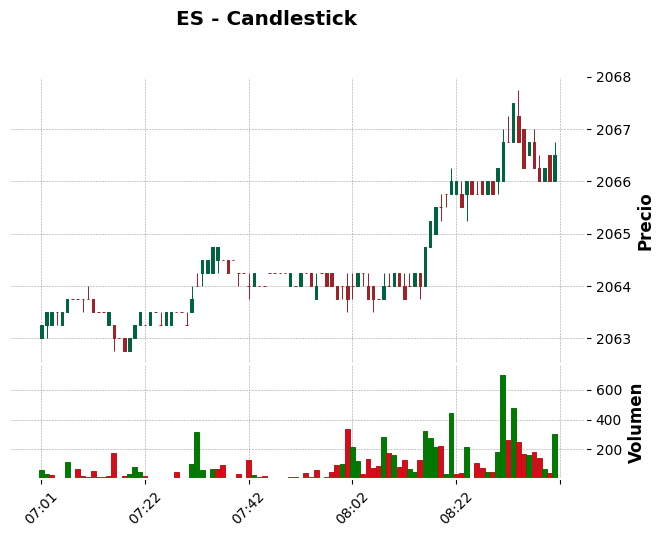

In [ ]:

import mplfinance as mpf
df_sample = df_es1min.iloc[:100]
mpf.plot(
    df_sample,
    type="candle",
    volume=True,
    style="charles",
    title="ES - Candlestick",
    ylabel="Precio",
    ylabel_lower="Volumen",
    columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOL"]
)

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


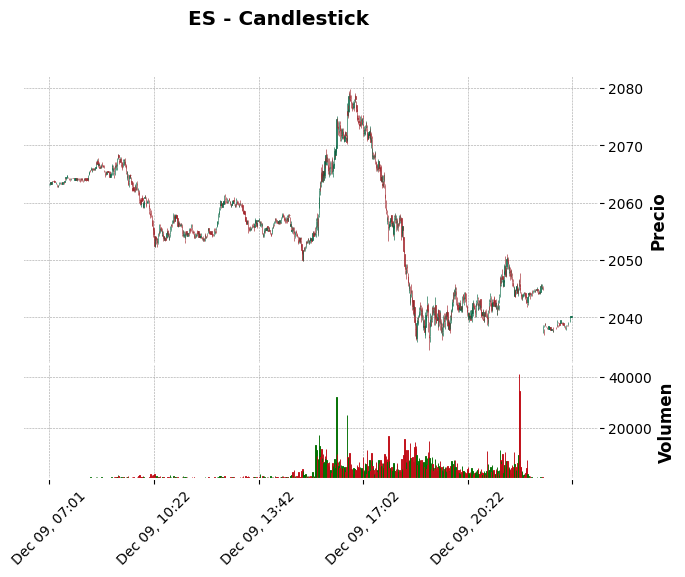

In [ ]:
import mplfinance as mpf
df_sample = df_es1min.iloc[:1000]
mpf.plot(
    df_sample,
    type="candle",
    volume=True,
    style="charles",
    title="ES - Candlestick",
    ylabel="Precio",
    ylabel_lower="Volumen",
    columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOL"]
)

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


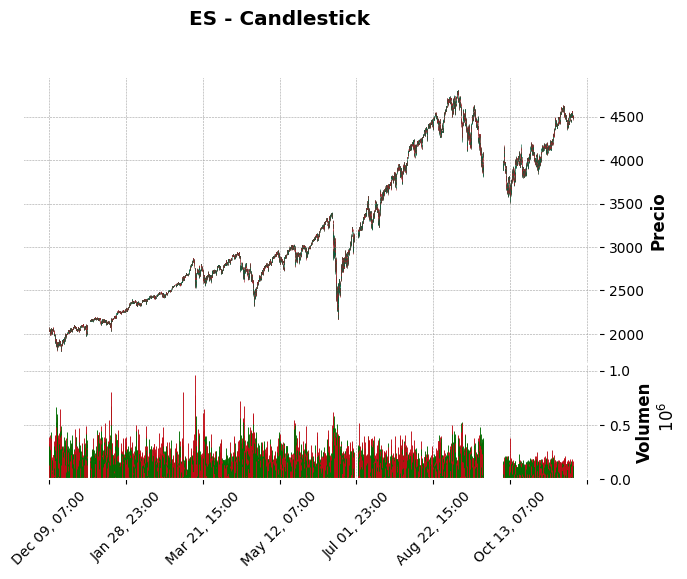

In [ ]:

df_1h = df_es1min.resample("1h").agg({
    "OPEN": "first",
    "HIGH": "max",
    "LOW": "min",
    "CLOSE": "last",
    "VOL":"sum"
})
df_1h_sample = df_1h
mpf.plot(
    df_1h_sample,
    type="candle",
    volume=True,
    style="charles",
    title="ES - Candlestick",
    ylabel="Precio",
    ylabel_lower="Volumen",
    columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOL"]
)

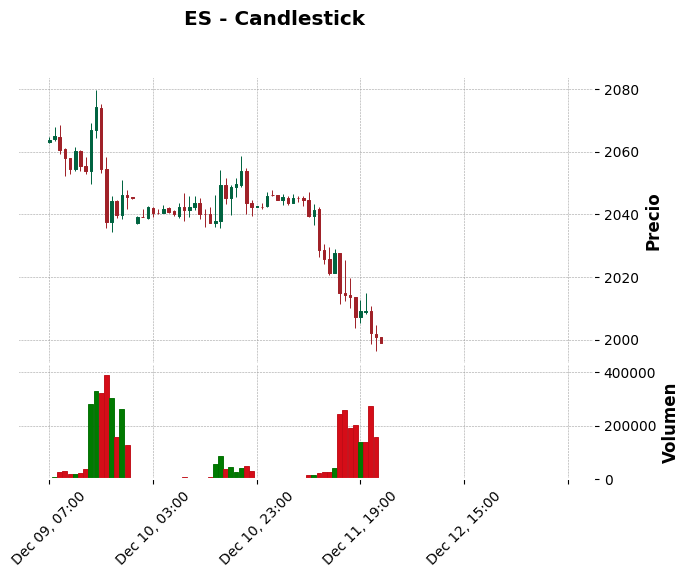

In [ ]:
df_1h_sample = df_1h.iloc[:100]
mpf.plot(
    df_1h_sample,
    type="candle",
    volume=True,
    style="charles",
    title="ES - Candlestick",
    ylabel="Precio",
    ylabel_lower="Volumen",
    columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOL"]
)

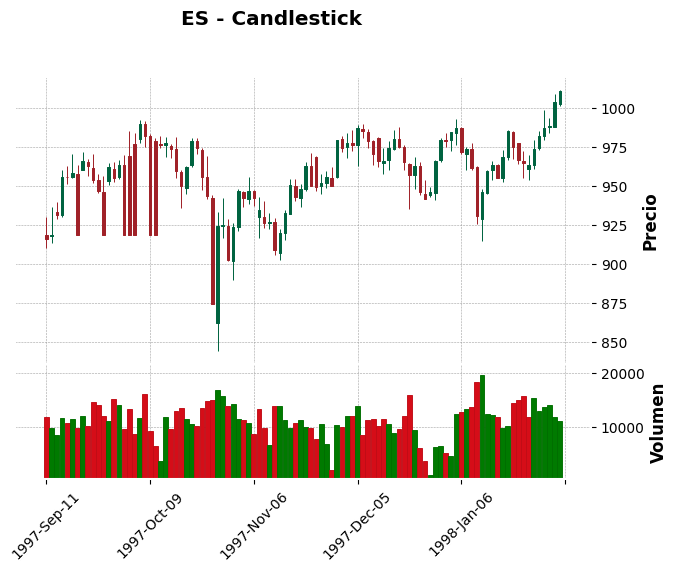

In [ ]:
df_es1dia_sample = df_es1dia.iloc[:100]
mpf.plot(
    df_es1dia_sample,
    type="candle",
    volume=True,
    style="charles",
    title="ES - Candlestick",
    ylabel="Precio",
    ylabel_lower="Volumen",
    columns=["OPEN", "HIGH", "LOW", "CLOSE", "VOL"]
)

# Comienzo de aplicación de regresión lineal para sistemas ORB.

Definimos la función displ= ((high+low)/2)- open  Para el día. Para ello guardamos los máximos, mínimos y de apertura en vectoeres.

In [ ]:
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
datetime,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516
...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081


In [ ]:
high = df_es1dia['HIGH']
low = df_es1dia['LOW']
open = df_es1dia['OPEN']

In [ ]:
def displ(high, low, open):
  return ((high+low)/2)- open
display = displ(high, low, open)

In [ ]:
df_es1dia['DISPLAY'] = display

In [ ]:
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DISPLAY
datetime,,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1.250
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,7.000
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,0.875
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,13.875
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1.000
...,...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,19.250
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,-26.500
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,1.250


Ahora se va a determinar BULLISH (es un valor que depende de displ, en caso de que displ sea positivo implica que  es verdadero, si es falso es que es negativo)

In [ ]:
df_es1dia['BULLISH'] = df_es1dia['DISPLAY'] > 0


In [ ]:
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DISPLAY,BULLISH
datetime,,,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1.250,True
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,7.000,True
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,0.875,True
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,13.875,True
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1.000,True
...,...,...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,19.250,True
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,-26.500,False
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,1.250,True


Definición del set de predictor en base a días anteriores:
1.   El vector de características incorporará variables que se corresponden con los 5 días anteriores. (Cómo la media o varianza).
2. Así mismo también incorporará variables del intervalo tomado al principio del día.

Variables:
- p5_close_open, p4_close_open, p3_close_open, p2_close_open, p1_close_open. Se corresponderán conn los vectores de características, p5 indica que es de 5 días antes, p4 de cuatro día antes... Se corresponde con el valor de cierre menos el valor de apertura.
- La media y la desviación típica de estos 5 valores en los días anteriores se incorpora también (p_close_open_mean y p_close_open_sd)



In [ ]:
df_es1dia['CLOSE_OPEN'] = df_es1dia['CLOSE'] - df_es1dia['OPEN']

In [ ]:
df_es1dia['p5_close_open'] = df_es1dia['CLOSE_OPEN'].shift(5)
df_es1dia['p4_close_open'] = df_es1dia['CLOSE_OPEN'].shift(4)
df_es1dia['p3_close_open'] = df_es1dia['CLOSE_OPEN'].shift(3)
df_es1dia['p2_close_open'] = df_es1dia['CLOSE_OPEN'].shift(2)
df_es1dia['p1_close_open'] = df_es1dia['CLOSE_OPEN'].shift(1)

In [ ]:
df_es1dia['p_close_open_mean'] = df_es1dia[['p5_close_open', 'p4_close_open', 'p3_close_open', 'p2_close_open', 'p1_close_open']].mean(axis=1)
df_es1dia['p_close_open_sd']= df_es1dia[['p5_close_open', 'p4_close_open', 'p3_close_open', 'p2_close_open', 'p1_close_open']].std(axis=1)

In [ ]:
df_es1dia['p5_high_low'] = df_es1dia['HIGH'].shift(5) - df_es1dia['LOW'].shift(5)
df_es1dia['p4_high_low'] = df_es1dia['HIGH'].shift(4) - df_es1dia['LOW'].shift(4)
df_es1dia['p3_high_low'] = df_es1dia['HIGH'].shift(3) - df_es1dia['LOW'].shift(3)
df_es1dia['p2_high_low'] = df_es1dia['HIGH'].shift(2) - df_es1dia['LOW'].shift(2)
df_es1dia['p1_high_low'] = df_es1dia['HIGH'].shift(1) - df_es1dia['LOW'].shift(1)

In [ ]:
df_es1dia['p5_is_bullish'] = df_es1dia['BULLISH'].shift(5)
df_es1dia['p4_is_bullish'] = df_es1dia['BULLISH'].shift(4)
df_es1dia['p3_is_bullish'] = df_es1dia['BULLISH'].shift(3)
df_es1dia['p2_is_bullish'] = df_es1dia['BULLISH'].shift(2)
df_es1dia['p1_is_bullish'] = df_es1dia['BULLISH'].shift(1)

In [ ]:
df_es1dia['HINGE'] =(df_es1dia['HIGH'] - df_es1dia['LOW']) / 2


In [ ]:
df_es1dia['p5_HINGE'] = df_es1dia['HINGE'].shift(5)
df_es1dia['p4_HINGE'] = df_es1dia['HINGE'].shift(4)
df_es1dia['p3_HINGE'] = df_es1dia['HINGE'].shift(3)
df_es1dia['p2_HINGE'] = df_es1dia['HINGE'].shift(2)
df_es1dia['p1_HINGE'] = df_es1dia['HINGE'].shift(1)
df_es1dia['p_HINGE_mean'] = df_es1dia[['p5_HINGE', 'p4_HINGE', 'p3_HINGE', 'p2_HINGE', 'p1_HINGE']].mean(axis=1)
df_es1dia['p_HINGE_sd']= df_es1dia[['p5_HINGE', 'p4_HINGE', 'p3_HINGE', 'p2_HINGE', 'p1_HINGE']].std(axis=1)

In [ ]:
df_es1dia['p5_volume'] = df_es1dia['VOL'].shift(5)
df_es1dia['p4_volume'] = df_es1dia['VOL'].shift(4)
df_es1dia['p3_volume'] = df_es1dia['VOL'].shift(3)
df_es1dia['p2_volume'] = df_es1dia['VOL'].shift(2)
df_es1dia['p1_volume'] = df_es1dia['VOL'].shift(1)
df_es1dia['p_volume_mean'] = df_es1dia[['p5_volume', 'p4_volume', 'p3_volume', 'p2_volume', 'p1_volume']].mean(axis=1)
df_es1dia['p_volume_sd']= df_es1dia[['p5_volume', 'p4_volume', 'p3_volume', 'p2_volume', 'p1_volume']].std(axis=1)


In [ ]:
df_es1dia['p5_display'] = df_es1dia['DISPLAY'].shift(5)
df_es1dia['p4_display'] = df_es1dia['DISPLAY'].shift(4)
df_es1dia['p3_display'] = df_es1dia['DISPLAY'].shift(3)
df_es1dia['p2_display'] = df_es1dia['DISPLAY'].shift(2)
df_es1dia['p1_display'] = df_es1dia['DISPLAY'].shift(1)

In [ ]:
df_es1dia.head()


,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DISPLAY,...,p3_volume,p2_volume,p1_volume,p_volume_mean,p_volume_sd,p5_display,p4_display,p3_display,p2_display,p1_display
datetime,,,,,,,,,,,,,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,7.000,...,NaN,NaN,11825.0,11825.0,NaN,NaN,NaN,NaN,NaN,1.250
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,0.875,...,NaN,11825.0,9759.0,10792.0,1460.882610,NaN,NaN,NaN,1.250,7.000
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,13.875,...,11825.0,9759.0,8551.0,10045.0,1655.631602,NaN,NaN,1.25,7.000,0.875
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1.000,...,9759.0,8551.0,11749.0,10471.0,1597.909468,NaN,1.25,7.00,0.875,13.875


In [ ]:
df_es1dia.dropna()

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DISPLAY,...,p3_volume,p2_volume,p1_volume,p_volume_mean,p_volume_sd,p5_display,p4_display,p3_display,p2_display,p1_display
datetime,,,,,,,,,,,,,,,,,,,,,
1997-09-18,ES,D,0,955.75,970.50,954.75,958.00,11588,6122,6.875,...,8551.0,11749.0,10849.0,10546.6,1394.117212,1.250,7.000,0.875,13.875,1.000
1997-09-19,ES,D,0,957.75,963.25,918.75,918.75,9880,5836,-16.750,...,11749.0,10849.0,11588.0,10499.2,1342.872369,7.000,0.875,13.875,1.000,6.875
1997-09-22,ES,D,0,960.25,972.00,960.25,966.00,12076,5993,5.875,...,10849.0,11588.0,9880.0,10523.4,1327.197159,0.875,13.875,1.000,6.875,-16.750
1997-09-23,ES,D,0,965.25,967.25,956.50,962.50,10148,5679,-3.375,...,11588.0,9880.0,12076.0,11228.4,877.623097,13.875,1.000,6.875,-16.750,5.875
1997-09-24,ES,D,0,961.50,970.50,952.00,953.50,14580,6194,-0.250,...,9880.0,12076.0,10148.0,10908.2,930.656865,1.000,6.875,-16.750,5.875,-3.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,19.250,...,2023612.0,1853517.0,1729090.0,1603293.2,446244.260220,-16.500,2.250,12.125,-13.375,-0.375
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,-26.500,...,1853517.0,1729090.0,1600931.0,1615469.2,444915.859564,2.250,12.125,-13.375,-0.375,19.250
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,1.250,...,1729090.0,1600931.0,1708046.0,1783039.2,161663.450667,12.125,-13.375,-0.375,19.250,-26.500


Comenzamos con una aproximación para hacer predicciones en base a los días anteriores (todavía no contamos con los datos iniciales del propio día)

In [ ]:
df_es1dia.columns.tolist()

['TICKER',
 'PER',
 'TIME',
 'OPEN',
 'HIGH',
 'LOW',
 'CLOSE',
 'VOL',
 'OPENINT',
 'DISPLAY',
 'BULLISH',
 'CLOSE_OPEN',
 'p5_close_open',
 'p4_close_open',
 'p3_close_open',
 'p2_close_open',
 'p1_close_open',
 'p_close_open_mean',
 'p_close_open_sd',
 'p5_high_low',
 'p4_high_low',
 'p3_high_low',
 'p2_high_low',
 'p1_high_low',
 'p5_is_bullish',
 'p4_is_bullish',
 'p3_is_bullish',
 'p2_is_bullish',
 'p1_is_bullish',
 'HINGE',
 'p5_HINGE',
 'p4_HINGE',
 'p3_HINGE',
 'p2_HINGE',
 'p1_HINGE',
 'p_HINGE_mean',
 'p_HINGE_sd',
 'p5_volume',
 'p4_volume',
 'p3_volume',
 'p2_volume',
 'p1_volume',
 'p_volume_mean',
 'p_volume_sd',
 'p5_display',
 'p4_display',
 'p3_display',
 'p2_display',
 'p1_display']

In [ ]:
features = [
    'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open',
    'p_close_open_mean', 'p_close_open_sd', 'OPEN',
    'p1_high_low', 'p2_high_low', 'p3_high_low', 'p4_high_low', 'p5_high_low',
    'p1_is_bullish', 'p2_is_bullish', 'p3_is_bullish', 'p4_is_bullish', 'p5_is_bullish',
    'p1_HINGE', 'p2_HINGE', 'p3_HINGE', 'p4_HINGE', 'p5_HINGE',
    'p_HINGE_mean', 'p_HINGE_sd',
    'p1_volume', 'p2_volume', 'p3_volume', 'p4_volume', 'p5_volume',
    'p_volume_mean', 'p_volume_sd',  'p5_display', 'p4_display', 'p3_display', 'p2_display', 'p1_display'
]


In [ ]:
from sklearn.model_selection import train_test_split
df_model = df_es1dia.dropna()
X = df_model[features].astype(float)
y = df_model['BULLISH'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.65      0.56       656
           1       0.50      0.34      0.40       664

    accuracy                           0.49      1320
   macro avg       0.50      0.50      0.48      1320
weighted avg       0.50      0.49      0.48      1320

[[427 229]
 [438 226]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Entender resutlados, por una posible correlación, por si no hay nada que esté correlacionado de forma que no haya un poder predictivo lineal...

In [ ]:
import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np

correlations = {}
for col in X.columns:
    corr, _ = pointbiserialr(X[col], y)
    correlations[col] = corr

correlations = pd.Series(correlations).sort_values(key=abs, ascending=False)
correlations


,0
p5_volume,0.026398
p4_volume,0.023384
p_volume_mean,0.023000
p1_volume,0.021376
p2_is_bullish,-0.019745
p2_volume,0.018120
p3_volume,0.017395
p3_is_bullish,-0.016712
p4_is_bullish,-0.015198
p1_is_bullish,-0.015194


AÑADIR VARIABLES PARA INTENTAR OBTENER MEJORES RESULTADOS:


In [ ]:
df = df_es1dia.copy()
# GAPS comportamiento al abrir el mercado

df['prev_close'] = df['CLOSE'].shift(1)
# Gap absoluto: diferencia OPEN de hoy - CLOSE de ayer
df['gap_abs'] = df['OPEN'] - df['prev_close']


# Gap porcentual: gap relativo al precio -> Normaliza épocas de precios distintos.
df['gap_pct'] = df['gap_abs'] / df['prev_close']

# Dirección del gap: 1 si gap alcista, 0 si bajista.
df['gap_dir'] = np.where(df['gap_abs'] > 0, 1, 0)

# Gap Z-score: indica si el gap de hoy es inusualmente grande.
df['gap_zscore'] = (df['gap_pct'] - df['gap_pct'].rolling(20).mean()) / df['gap_pct'].rolling(20).std()

# TRUE RANGE y ATR (volatilidad real del día)
# High y low del día previo (para true range)
df['prev_high'] = df['HIGH'].shift(1)
df['prev_low'] = df['LOW'].shift(1)

# True Range: volatilidad real combinando rangos y gaps
df['true_range'] = df[['HIGH', 'LOW']].apply(lambda x: x['HIGH'] - x['LOW'], axis=1)
df['true_range'] = np.maximum(df['true_range'], np.abs(df['HIGH'] - df['prev_close']))
df['true_range'] = np.maximum(df['true_range'], np.abs(df['LOW'] - df['prev_close']))

# ATR a 5 días: volatilidad reciente
df['ATR_5'] = df['true_range'].rolling(5).mean()
# ATR a 10 días: volatilidad un poco más estable
df['ATR_10'] = df['true_range'].rolling(10).mean()
# ATR Z-score: mide si la volatilidad actual es anormal
df['ATR_zscore'] = (df['ATR_5'] - df['ATR_5'].rolling(20).mean()) / df['ATR_5'].rolling(20).std()

# Régimen de volatilidad: indica si la volatilidad está expandiendo (>1) o contrayendo (<1)
df['vol_regime'] = df['ATR_5'] / df['ATR_10']
# Medias móviles: tendencia corta vs media
df['MA5'] = df['CLOSE'].rolling(5).mean()
df['MA20'] = df['CLOSE'].rolling(20).mean()
# Cross de medias: 1 si MA5 > MA20 → tendencia alcista
df['trend_MA_cross'] = (df['MA5'] > df['MA20']).astype(int)

# Valores del primer minuto → en datos diarios coincide con la barra del día
df['ini_close'] = df['CLOSE']
df['ini_high'] = df['HIGH']
df['ini_low'] = df['LOW']

# Cierre del primer minuto relativo a apertura
df['ini_close_rel'] = df['ini_close'] / df['OPEN'] - 1

# Caída desde apertura en el primer minuto
df['ini_low_open'] = df['ini_low'] - df['OPEN']

# Subida desde apertura en el primer minuto
df['ini_high_open'] = df['ini_high'] - df['OPEN']

# Rango completo del primer minuto (volatilidad intradía inmediata)
df['ini_range'] = df['ini_high'] - df['ini_low']

# Volatilidad del primer minuto en términos relativos
df['ini_volatility'] = df['ini_range'] / df['OPEN']

# 5. MICROESTRUCTURA INICIAL (mechas, cuerpo, rechazo)
# Detectar fakeouts en ORB
# Tamaño del cuerpo del primer minuto
df['ini_body'] = np.abs(df['ini_close'] - df['OPEN'])

# Qué proporción del rango es direccional (cuerpo) vs ruido (mechas)
df['ini_body_ratio'] = df['ini_body'] / df['ini_range'].replace(0, np.nan)

# Mecha superior del primer minuto (rechazo por arriba)
df['ini_wick_up'] = df['ini_high'] - np.maximum(df['OPEN'], df['ini_close'])

# Mecha inferior del primer minuto (rechazo por abajo)
df['ini_wick_down'] = np.minimum(df['OPEN'], df['ini_close']) - df['ini_low']

# Relación entre mechas: indica qué lado está siendo rechazado
df['ini_wick_ratio'] = df['ini_wick_up'] / df['ini_wick_down'].replace(0, np.nan)


# Secuencia de los últimos 5 valores "is bullish"
# Captura patrones multi-día (muy potente en este tipo de modelos)
df['seq_is_bullish'] = (
    df['p5_is_bullish'].astype(str) + "_" +
    df['p4_is_bullish'].astype(str) + "_" +
    df['p3_is_bullish'].astype(str) + "_" +
    df['p2_is_bullish'].astype(str) + "_" +
    df['p1_is_bullish'].astype(str)
)

# Dirección del hinge (expansión/contracción del rango diario)
df['hinge_dir'] = np.where(df['HINGE'] > df['HINGE'].rolling(5).mean(), 1, 0)

# Secuencia categórica de cambios en hinge
df['seq_hinge_dir'] = (
    df['p5_HINGE'].diff().fillna(0).astype(int).astype(str) + "_" +
    df['p4_HINGE'].diff().fillna(0).astype(int).astype(str) + "_" +
    df['p3_HINGE'].diff().fillna(0).astype(int).astype(str) + "_" +
    df['p2_HINGE'].diff().fillna(0).astype(int).astype(str) + "_" +
    df['p1_HINGE'].diff().fillna(0).astype(int).astype(str)
)
¡
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [ ]:
df_model1 = df
X = df_model1[features].astype(float)
y = df_model1['BULLISH'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [ ]:
log_model1 = LogisticRegression(max_iter=1000)
log_model1.fit(X_train, y_train)

y_pred = log_model1.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.68      0.57       646
           1       0.50      0.31      0.38       651

    accuracy                           0.49      1297
   macro avg       0.50      0.50      0.48      1297
weighted avg       0.50      0.49      0.48      1297

[[440 206]
 [449 202]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


df_model1 = df
X = df_model1[features].astype(float)
y = df_model1['BULLISH'].astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Selección automática de las TOP 20 features

mi = mutual_info_classif(X_scaled, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

top_features = mi_series.head(20).index
print("TOP FEATURES:\n", top_features)

X_top = X_scaled[:, :20]
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, shuffle=False, test_size=0.2
)

log_model1 = LogisticRegression(
    max_iter=5000,
    C=1.0,
    solver='lbfgs'
)

log_model1.fit(X_train, y_train)

y_pred = log_model1.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


TOP FEATURES:
 Index(['p3_is_bullish', 'p1_is_bullish', 'p2_high_low', 'p2_display',
       'p4_is_bullish', 'p2_volume', 'p5_is_bullish', 'p3_volume', 'p1_HINGE',
       'p_close_open_sd', 'p5_display', 'p2_HINGE', 'p2_is_bullish',
       'p4_high_low', 'p1_close_open', 'p_volume_sd', 'p5_close_open',
       'p1_volume', 'p4_close_open', 'p_HINGE_mean'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.46      0.22      0.29       646
           1       0.49      0.75      0.60       651

    accuracy                           0.49      1297
   macro avg       0.48      0.48      0.44      1297
weighted avg       0.48      0.49      0.45      1297

[[139 507]
 [160 491]]


Probamos con otro modelo a ver que pasa, este no consigue resultados ni para atraás


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.48      0.29      0.37       656
           1       0.50      0.69      0.58       665

    accuracy                           0.49      1321
   macro avg       0.49      0.49      0.47      1321
weighted avg       0.49      0.49      0.47      1321


=== CONFUSION MATRIX ===
[[193 463]
 [206 459]]

=== ROC AUC ===
0.5052448193654869


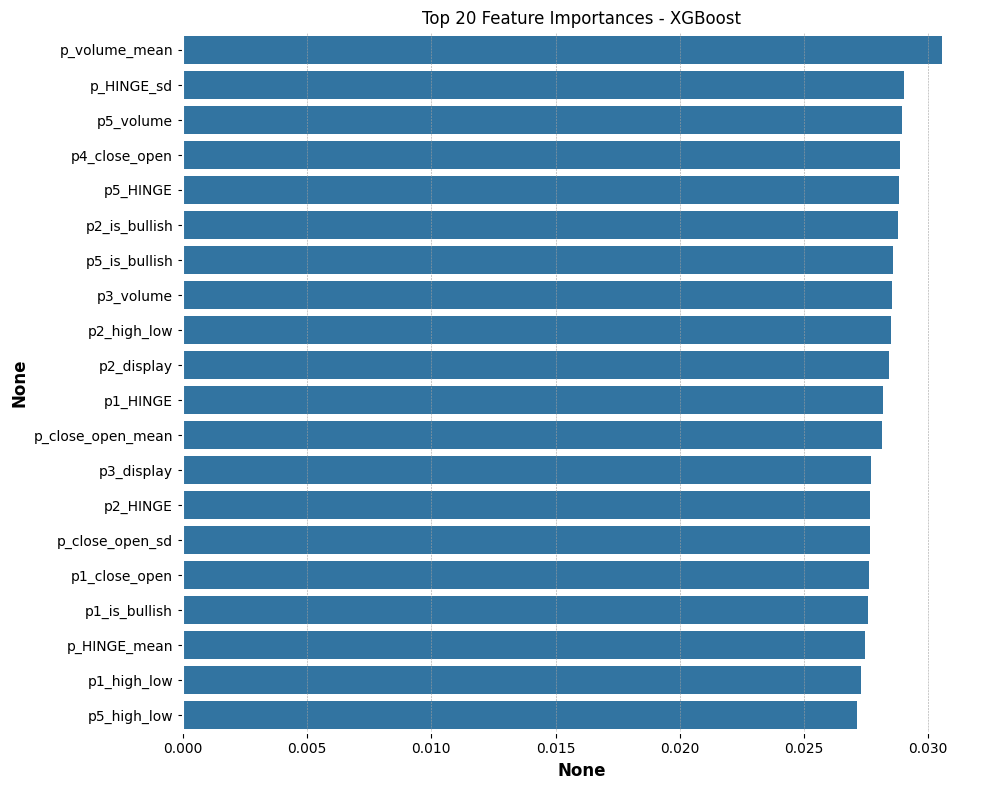

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from xgboost import XGBClassifier

df_model = df_es1dia.copy()

X = df_model[features].astype(float)
y = df_model['BULLISH'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)


xgb_model = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=3,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train)

y_scores = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_scores > threshold).astype(int)


print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== ROC AUC ===")
print(roc_auc_score(y_test, y_scores))


import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importance.head(20), y=importance.head(20).index)
plt.title("Top 20 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.50      0.32      0.39       646
           1       0.51      0.69      0.58       651

    accuracy                           0.51      1297
   macro avg       0.50      0.50      0.49      1297
weighted avg       0.50      0.51      0.49      1297


=== CONFUSION MATRIX ===
[[209 437]
 [205 446]]

=== ROC AUC ===
0.5136346558997114


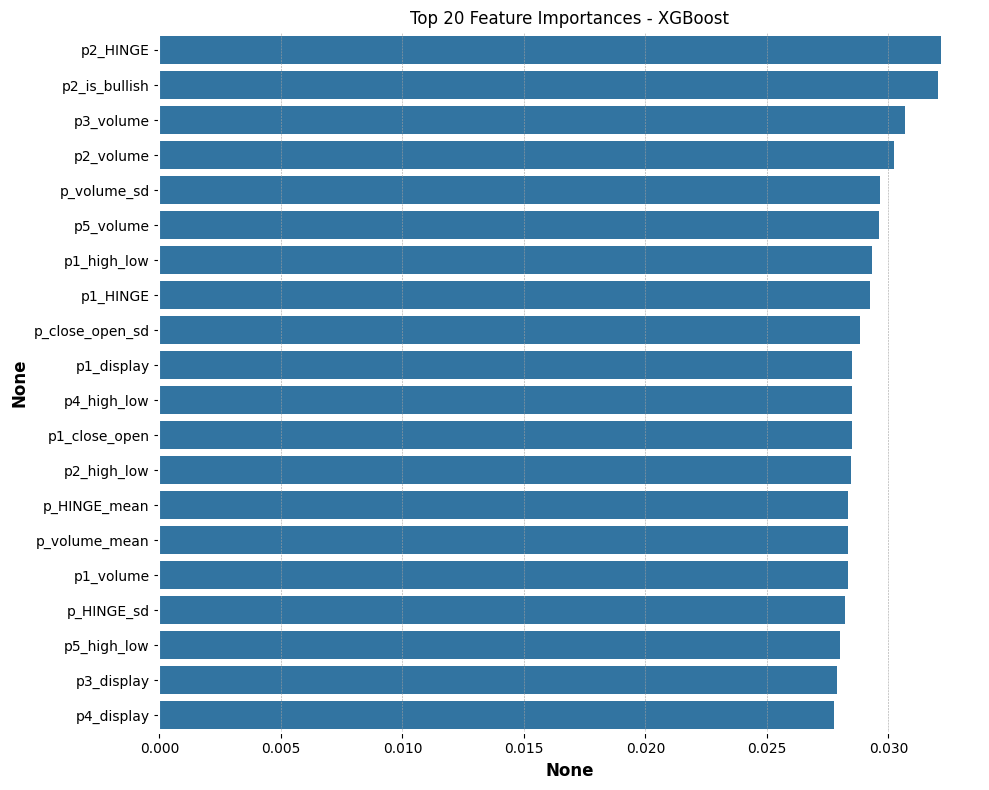

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from xgboost import XGBClassifier

df_model = df.copy()

X = df_model[features].astype(float)
y = df_model['BULLISH'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)


xgb_model = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=3,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train)
y_scores = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_scores > threshold).astype(int)


print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== ROC AUC ===")
print(roc_auc_score(y_test, y_scores))

import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importance.head(20), y=importance.head(20).index)
plt.title("Top 20 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()
